In [1]:
import geopandas as gpd
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
sns.set_style('white')

In [2]:
# Read in the shapefile for Maryland
shapefile_path = '/glade/derecho/scratch/dcalhoun/census/shapefiles/nhgis0001_shapefile_tl2023_us_county_2023'
gdf = gpd.read_file(shapefile_path, columns=['GEOID', 'STATEFP', 'geometry']).to_crs('WGS84')
gdf = gdf[gdf['STATEFP'] == '24'][['GEOID', 'geometry']].reset_index(drop=True)
gdf.head()

,GEOID,geometry
0,24001,"POLYGON ((-78.34283 39.72226, -78.34273 39.722..."
1,24003,"MULTIPOLYGON (((-76.53323 38.8869, -76.53327 3..."
2,24005,"MULTIPOLYGON (((-76.50015 39.24931, -76.49987 ..."
3,24009,"MULTIPOLYGON (((-76.45425 38.3225, -76.45405 3..."
4,24011,"POLYGON ((-75.72279 38.82985, -75.72236 38.824..."


In [3]:
# Read in the census data
census_files = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/census/data/acs_5yr_2023/county/Maryland/*.csv'))
dataframes = []
df = None
for i, census_file in enumerate(census_files):
    if i != len(census_files) - 1:
        df = pd.read_csv(census_file)
        ncols = len(df.columns)
        df = pd.read_csv(census_file, usecols=range(ncols - 4))
        dataframes.append(df)
    else:
        df = pd.read_csv(census_file)
        dataframes.append(df)
df_census = pd.concat(dataframes, axis=1)

# Clean up the census data
df_census.drop(columns=['Unnamed: 0'], inplace=True) # Drop duplicate index column
df_census['GEOID'] = df_census['GEO_ID'].str.slice(-5) # Extract the shortened GEOID from the GEO_ID column
df_census.drop(columns=['GEO_ID'], inplace=True) # Drop the original GEO_ID column
cols = df_census.columns.tolist()
new_order = cols[-3:] + cols[:-3]
df_census = df_census[new_order] # Reorder columns
df_census.rename(columns={'state': 'STATEFP', 'county': 'COUNTYFP'}, inplace=True) # Rename columns

# Split estimates and margins of error into separate DataFrames
retain_columns = ['GEOID', 'NAME', 'STATEFP', 'COUNTYFP']
df_census_est = df_census[[col for col in df_census.columns if col not in retain_columns and col.endswith('E')]].copy()
df_census_moe = df_census[[col for col in df_census.columns if col not in retain_columns and col.endswith('M')]].copy()
df_census_est.columns = df_census_est.columns.str[:-1]
df_census_moe.columns = df_census_moe.columns.str[:-1]
df_census_est = pd.concat([df_census[retain_columns], df_census_est], axis=1)
df_census_moe = pd.concat([df_census[retain_columns], df_census_moe], axis=1)

df_census_est.head()

,GEOID,NAME,STATEFP,COUNTYFP,B01001_001,B01001_002,B01001_003,B01001_004,B01001_005,B01001_006,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
0,24001,"Allegany County, Maryland",24,1,67762,35357,1588,1900,1671,1093,...,29483,32810,32810,27436,5374,27436,19294,8142,786,149200
1,24003,"Anne Arundel County, Maryland",24,3,590936,292506,18141,18728,19943,11393,...,144719,234843,234843,223602,11241,223602,167618,55984,1990,450300
2,24005,"Baltimore County, Maryland",24,5,849586,404133,24970,26150,27069,16648,...,233100,350296,350296,330151,20145,330151,218994,111157,1566,330000
3,24009,"Calvert County, Maryland",24,9,93791,46707,2543,3457,3108,2085,...,24305,35960,35960,33485,2475,33485,29184,4301,1701,440200
4,24011,"Caroline County, Maryland",24,11,33406,16442,1048,1318,939,733,...,9789,13516,13516,12181,1335,12181,8753,3428,1070,272400


In [4]:
# Read in aggregated data
agg_filenames = sorted(glob.glob('/glade/derecho/scratch/dcalhoun/aggregated/county/Maryland/ifs/0.125/t2m/00/24/*/*/*.csv'))
dfs = []
for filename in agg_filenames:
    df = pd.read_csv(filename, index_col=0)
    df['GEOID'] = df['GEOID'].astype(str)
    df['time'] = pd.to_datetime(df['time'])
    df['Year'] = [d.strftime('%Y') for d in df['time']]
    df['Month'] = [d.strftime('%m') for d in df['time']]
    df['Day'] = [d.strftime('%d') for d in df['time']] 
    df.loc[df['Month'].isin(['12', '01', '02']), 'Season'] = 'DJF'
    df.loc[df['Month'].isin(['03', '04', '05']), 'Season'] = 'MAM'
    df.loc[df['Month'].isin(['06', '07', '08']), 'Season'] = 'JJA'
    df.loc[df['Month'].isin(['09', '10', '11']), 'Season'] = 'SON'
    df = pd.concat([df, df_census_est.copy().iloc[:,1:]], axis=1)
    dfs.append(df)
MD_error = pd.concat(dfs)
MD_error.reset_index(inplace=True, drop=True)

In [5]:
(MD_error['time'].min().strftime('%Y-%m-%d-%H'), MD_error['time'].max().strftime('%Y-%m-%d-%H'))

('2016-01-03-00', '2024-11-30-00')

In [6]:
MD_error.head()

,GEOID,time,t2m_abs_error,Year,Month,Day,Season,NAME,STATEFP,COUNTYFP,...,B23025_007,B25001_001,B25002_001,B25002_002,B25002_003,B25003_001,B25003_002,B25003_003,B25064_001,B25077_001
0,24001,2016-01-03,1.516969,2016,01,03,DJF,"Allegany County, Maryland",24,1,...,29483,32810,32810,27436,5374,27436,19294,8142,786,149200
1,24003,2016-01-03,1.088814,2016,01,03,DJF,"Anne Arundel County, Maryland",24,3,...,144719,234843,234843,223602,11241,223602,167618,55984,1990,450300
2,24005,2016-01-03,0.957353,2016,01,03,DJF,"Baltimore County, Maryland",24,5,...,233100,350296,350296,330151,20145,330151,218994,111157,1566,330000
3,24009,2016-01-03,0.331070,2016,01,03,DJF,"Calvert County, Maryland",24,9,...,24305,35960,35960,33485,2475,33485,29184,4301,1701,440200
4,24011,2016-01-03,0.414652,2016,01,03,DJF,"Caroline County, Maryland",24,11,...,9789,13516,13516,12181,1335,12181,8753,3428,1070,272400


### Error

In [7]:
pd.DataFrame(MD_error['t2m_abs_error'].describe())

,t2m_abs_error
count,75360.000000
mean,1.305818
std,0.912704
min,0.019265
25%,0.598989
50%,1.103690
75%,1.807507
max,10.913544


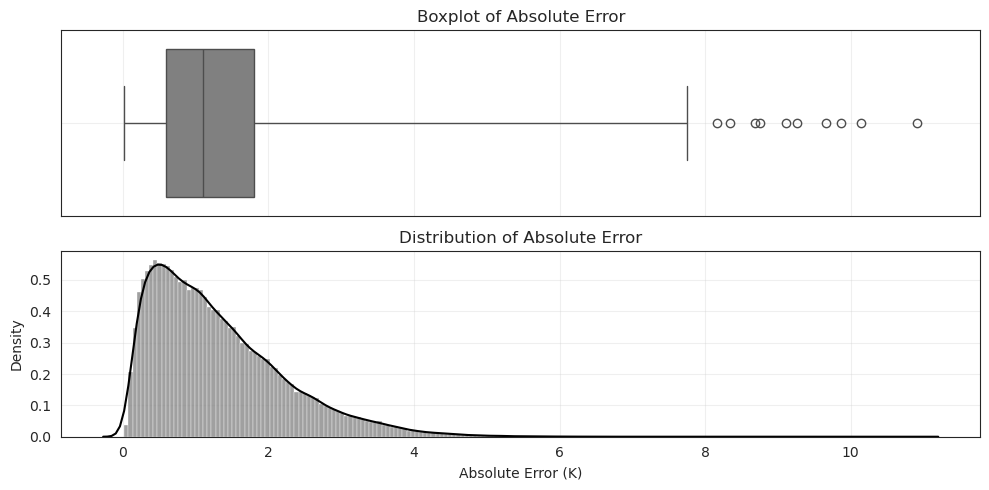

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(10,5), sharex=True)
sns.boxplot(data=MD_error, x='t2m_abs_error', whis=5, color='grey', ax=ax[0])
ax[0].set_xlabel('Absolute Error (K)')
ax[0].set_title('Boxplot of Absolute Error')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, x='t2m_abs_error', c='k', ax=ax[1])
sns.histplot(data=MD_error, x='t2m_abs_error', stat='density', color='grey', ax=ax[1])
ax[1].set_title('Distribution of Absolute Error')
ax[1].set_xlabel('Absolute Error (K)')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
MD_error['log_t2m_abs_error'] = np.log(MD_error['t2m_abs_error'])

In [10]:
pd.DataFrame(MD_error['log_t2m_abs_error'].describe())

,log_t2m_abs_error
count,75360.000000
mean,-0.005689
std,0.798486
min,-3.949449
25%,-0.512512
50%,0.098659
75%,0.591949
max,2.390005


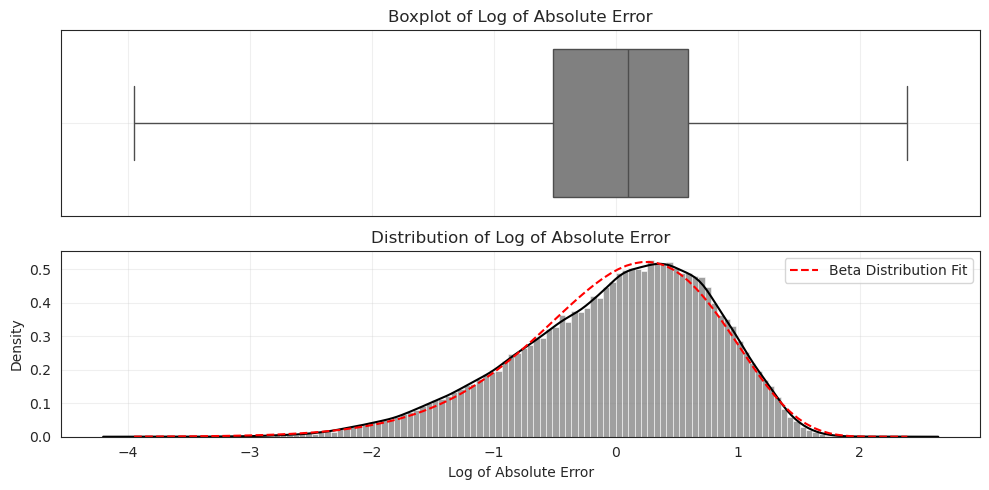

In [11]:
fig, ax = plt.subplots(2, 1, figsize=(10,5), sharex=True)
sns.boxplot(data=MD_error, x='log_t2m_abs_error', whis=5, color='grey', ax=ax[0])
ax[0].set_xlabel('Log of Absolute Error')
ax[0].set_title('Boxplot of Log of Absolute Error')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, x='log_t2m_abs_error', c='k', ax=ax[1])
sns.histplot(data=MD_error, x='log_t2m_abs_error', color='grey', stat='density', ax=ax[1])
ax[1].set_title('Distribution of Log of Absolute Error')
ax[1].set_xlabel('Log of Absolute Error')
ax[1].grid(alpha=0.3)

# Fit beta distribution
a, b, loc, scale = stats.beta.fit(MD_error['log_t2m_abs_error'])
x = np.linspace(MD_error['log_t2m_abs_error'].min(), MD_error['log_t2m_abs_error'].max(), 100)
p = stats.beta.pdf(x, a, b, loc=loc, scale=scale)
ax[1].plot(x, p, 'r', label='Beta Distribution Fit', linestyle='--')

plt.legend()
plt.tight_layout()
plt.show()

### Error by Year

In [12]:
pd.DataFrame(MD_error.groupby('Year')['t2m_abs_error'].describe())

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2016,8448.0,1.226706,0.903575,0.028923,0.525136,0.998594,1.706273,6.512156
2017,8448.0,1.326968,0.965778,0.031932,0.585553,1.093966,1.803122,5.445300
2018,8424.0,1.420096,0.968099,0.019265,0.651197,1.232560,1.978053,6.188012
2019,8472.0,1.397042,0.909793,0.054724,0.675222,1.225900,1.930693,6.006013
2020,8424.0,1.359134,0.924885,0.060832,0.669337,1.170060,1.857171,10.913544
2021,8448.0,1.312193,0.958692,0.044103,0.560391,1.066440,1.861136,5.993998
2022,8472.0,1.286489,0.870430,0.042364,0.617564,1.108154,1.764372,7.192492
2023,8472.0,1.254134,0.839184,0.037657,0.622321,1.078311,1.699612,6.037609
2024,7752.0,1.157822,0.825800,0.049304,0.512414,0.958960,1.626283,6.393770


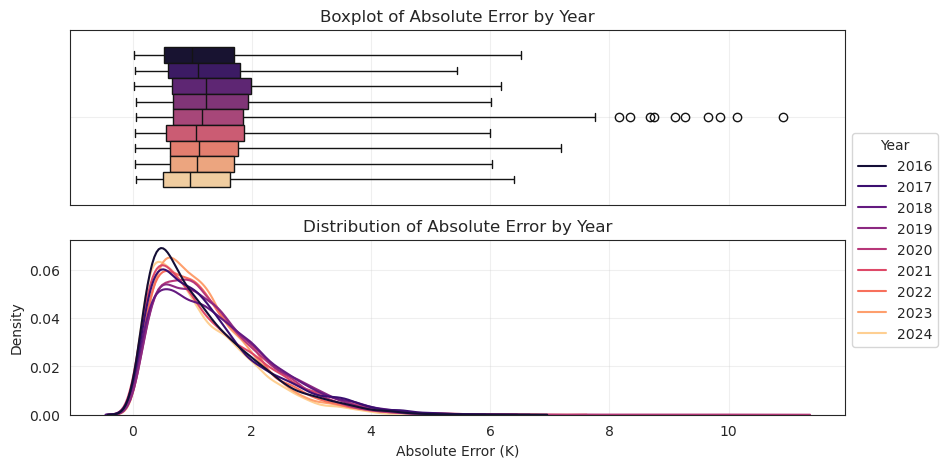

In [13]:
palette = sns.color_palette('magma', n_colors=9)

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

sns.boxplot(data=MD_error, x='t2m_abs_error', hue='Year', whis=5, palette=palette, ax=ax[0], legend=False)
ax[0].set_xlabel('Absolute Error (K)')
ax[0].set_title('Boxplot of Absolute Error by Year')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, hue='Year', x='t2m_abs_error', palette=palette, ax=ax[1])
ax[1].set_title('Distribution of Absolute Error by Year')
ax[1].set_xlabel('Absolute Error (K)')
ax[1].grid(alpha=0.3)

sns.move_legend(ax[1], "center left", bbox_to_anchor=(1, 1))
plt.show()

In [14]:
pd.DataFrame(MD_error.groupby('Year')['log_t2m_abs_error'].describe())

,count,mean,std,min,25%,50%,75%,max
Year,,,,,,,,
2016,8448.0,-0.090064,0.822147,-3.543118,-0.644099,-0.001408,0.534311,1.873671
2017,8448.0,-0.008963,0.823886,-3.444145,-0.535199,0.089810,0.589520,1.694753
2018,8424.0,0.074331,0.818318,-3.949449,-0.428943,0.209093,0.682113,1.822614
2019,8472.0,0.086408,0.766354,-2.905445,-0.392714,0.203676,0.657879,1.792761
2020,8424.0,0.061712,0.751868,-2.799639,-0.401468,0.157055,0.619054,2.390005
2021,8448.0,-0.031354,0.845135,-3.121220,-0.579121,0.064326,0.621187,1.790759
2022,8472.0,-0.003835,0.775367,-3.161448,-0.481973,0.102695,0.567795,1.973038
2023,8472.0,-0.013662,0.742282,-3.279223,-0.474299,0.075396,0.530400,1.798008
2024,7752.0,-0.136364,0.808840,-3.009755,-0.668623,-0.041906,0.486297,1.855324


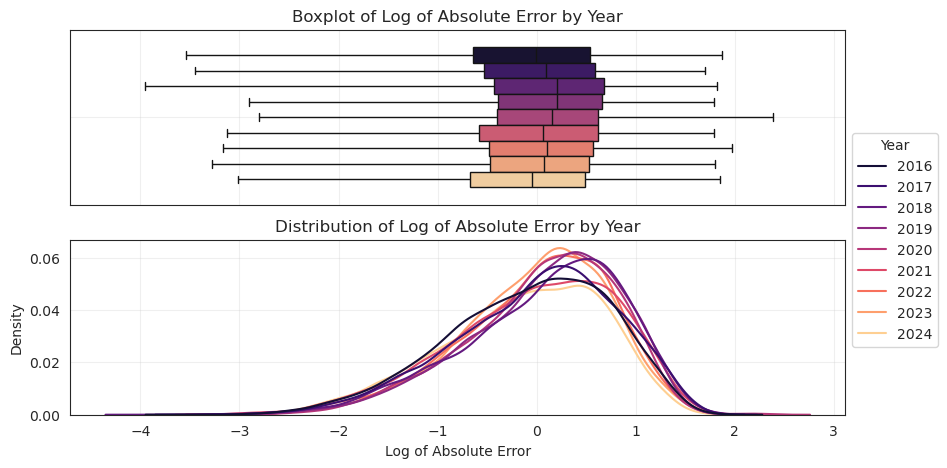

In [15]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

sns.boxplot(data=MD_error, x='log_t2m_abs_error', hue='Year', whis=5, palette=palette, ax=ax[0], legend=False)
ax[0].set_xlabel('Log of Absolute Error')
ax[0].set_title('Boxplot of Log of Absolute Error by Year')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, hue='Year', x='log_t2m_abs_error', palette=palette, ax=ax[1])
ax[1].set_title('Distribution of Log of Absolute Error by Year')
ax[1].set_xlabel('Log of Absolute Error')
ax[1].grid(alpha=0.3)

sns.move_legend(ax[1], "center left", bbox_to_anchor=(1, 1))
plt.show()

### Error by Month

In [16]:
pd.DataFrame(MD_error.groupby('Month')['t2m_abs_error'].describe())

,count,mean,std,min,25%,50%,75%,max
Month,,,,,,,,
01,6432.0,1.320864,0.809700,0.019265,0.669177,1.229453,1.842319,5.144168
02,5832.0,1.547232,1.074302,0.028923,0.725752,1.350526,2.127099,10.913544
03,6480.0,1.729993,1.054794,0.051314,0.833957,1.626808,2.462234,6.332714
04,6264.0,1.887550,1.158734,0.040053,0.949055,1.734620,2.684118,7.192492
05,6480.0,1.651504,1.055612,0.049311,0.769547,1.493307,2.338667,6.188012
06,6240.0,1.368203,0.818518,0.073169,0.702731,1.237569,1.894770,6.393770
07,6456.0,1.188998,0.759756,0.072333,0.616327,1.048232,1.577707,6.037609
08,6480.0,1.146904,0.675851,0.037369,0.632746,1.044078,1.550784,5.581041
09,6216.0,0.866308,0.570794,0.052101,0.435955,0.748647,1.162716,5.084526


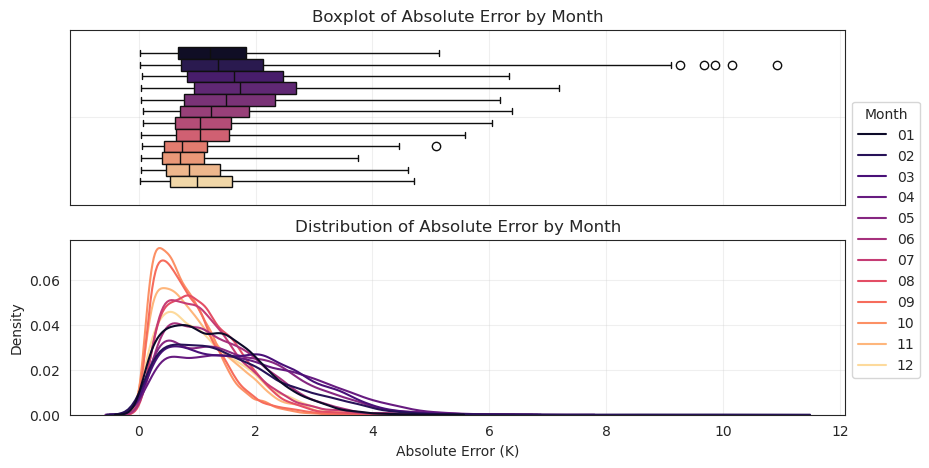

In [17]:
palette = sns.color_palette('magma', n_colors=12)

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

sns.boxplot(data=MD_error, x='t2m_abs_error', hue='Month', whis=5, palette=palette, ax=ax[0], legend=False)
ax[0].set_xlabel('Absolute Error (K)')
ax[0].set_title('Boxplot of Absolute Error by Month')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, hue='Month', x='t2m_abs_error', palette=palette, ax=ax[1])
ax[1].set_title('Distribution of Absolute Error by Month')
ax[1].set_xlabel('Absolute Error (K)')
ax[1].grid(alpha=0.3)

sns.move_legend(ax[1], "center left", bbox_to_anchor=(1, 1))
plt.show()

In [18]:
pd.DataFrame(MD_error.groupby('Month')['log_t2m_abs_error'].describe())

,count,mean,std,min,25%,50%,75%,max
Month,,,,,,,,
01,6432.0,0.034363,0.784458,-3.949449,-0.401706,0.206569,0.611025,1.637864
02,5832.0,0.153677,0.836693,-3.543118,-0.320547,0.300494,0.754759,2.390005
03,6480.0,0.296838,0.798197,-2.969790,-0.181573,0.486620,0.901069,1.845729
04,6264.0,0.385228,0.795906,-3.217548,-0.052288,0.550788,0.987352,1.973038
05,6480.0,0.240358,0.804819,-3.009605,-0.261953,0.400993,0.849581,1.822614
06,6240.0,0.101082,0.707998,-2.614980,-0.352781,0.213149,0.639097,1.855324
07,6456.0,-0.038909,0.687723,-2.626477,-0.483978,0.047105,0.455973,1.798008
08,6480.0,-0.054370,0.662238,-3.286920,-0.457686,0.043134,0.438760,1.719375
09,6216.0,-0.370612,0.712730,-2.954562,-0.830216,-0.289488,0.150758,1.626202


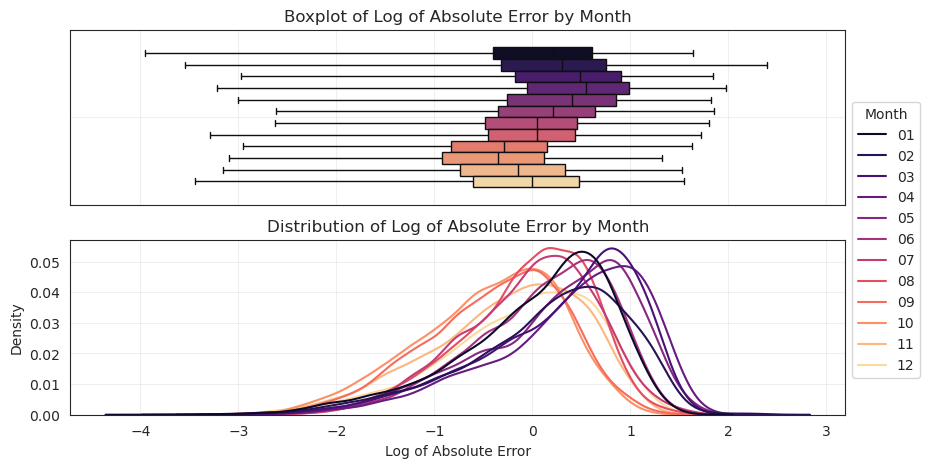

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

sns.boxplot(data=MD_error, x='log_t2m_abs_error', hue='Month', whis=5, palette=palette, ax=ax[0], legend=False)
ax[0].set_xlabel('Log of Absolute Error')
ax[0].set_title('Boxplot of Log of Absolute Error by Month')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, hue='Month', x='log_t2m_abs_error', palette=palette, ax=ax[1])
ax[1].set_title('Distribution of Log of Absolute Error by Month')
ax[1].set_xlabel('Log of Absolute Error')
ax[1].grid(alpha=0.3)

sns.move_legend(ax[1], "center left", bbox_to_anchor=(1, 1))
plt.show()

### Error by Season

In [20]:
pd.DataFrame(MD_error.groupby('Season')['t2m_abs_error'].describe())

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
DJF,18024.0,1.337193,0.903316,0.019265,0.636443,1.176995,1.853678,10.913544
JJA,19176.0,1.233088,0.758782,0.037369,0.647887,1.099448,1.664003,6.393770
MAM,19224.0,1.754875,1.094332,0.040053,0.845261,1.614553,2.492812,7.192492
SON,18936.0,0.893717,0.599153,0.042364,0.431735,0.766709,1.220580,5.084526


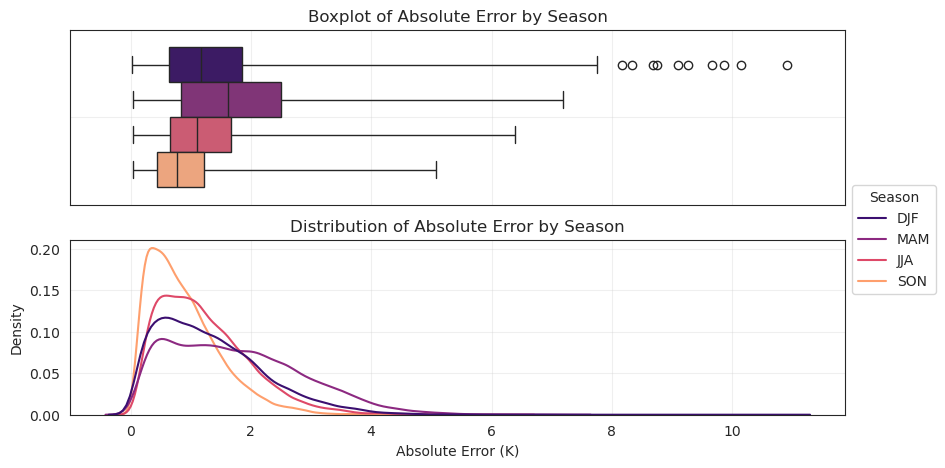

In [21]:
palette = sns.color_palette('magma', n_colors=4)

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

sns.boxplot(data=MD_error, x='t2m_abs_error', hue='Season', whis=5, palette=palette, ax=ax[0], legend=False)
ax[0].set_xlabel('Absolute Error (K)')
ax[0].set_title('Boxplot of Absolute Error by Season')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, hue='Season', x='t2m_abs_error', palette=palette, ax=ax[1])
ax[1].set_title('Distribution of Absolute Error by Season')
ax[1].set_xlabel('Absolute Error (K)')
ax[1].grid(alpha=0.3)

sns.move_legend(ax[1], "center left", bbox_to_anchor=(1, 1))
plt.show()

In [22]:
pd.DataFrame(MD_error.groupby('Season')['log_t2m_abs_error'].describe())

,count,mean,std,min,25%,50%,75%,max
Season,,,,,,,,
DJF,18024.0,0.021565,0.811864,-3.949449,-0.451860,0.162965,0.617172,2.390005
JJA,19176.0,0.001420,0.689440,-3.286920,-0.434039,0.094808,0.509226,1.855324
MAM,19224.0,0.306601,0.801851,-3.217548,-0.168110,0.479058,0.913411,1.973038
SON,18936.0,-0.355869,0.744049,-3.161448,-0.839944,-0.265648,0.199326,1.626202


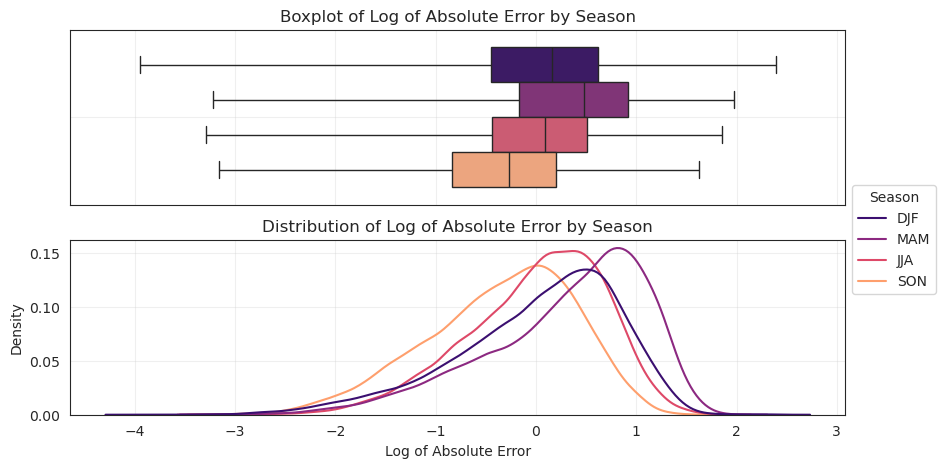

In [23]:
fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

sns.boxplot(data=MD_error, x='log_t2m_abs_error', hue='Season', whis=5, palette=palette, ax=ax[0], legend=False)
ax[0].set_xlabel('Log of Absolute Error')
ax[0].set_title('Boxplot of Log of Absolute Error by Season')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, hue='Season', x='log_t2m_abs_error', palette=palette, ax=ax[1])
ax[1].set_title('Distribution of Log of Absolute Error by Season')
ax[1].set_xlabel('Log of Absolute Error')
ax[1].grid(alpha=0.3)

sns.move_legend(ax[1], "center left", bbox_to_anchor=(1, 1))
plt.show()

### Error by GEOID

In [24]:
pd.DataFrame(MD_error.groupby('GEOID')['t2m_abs_error'].describe())

,count,mean,std,min,25%,50%,75%,max
GEOID,,,,,,,,
24001,3140.0,1.612778,1.078838,0.057745,0.754651,1.388275,2.216336,6.210293
24003,3140.0,1.230282,0.851030,0.046807,0.566987,1.035417,1.697974,10.913544
24005,3140.0,1.442448,0.945308,0.031932,0.690769,1.246974,1.988044,6.680454
24009,3140.0,1.118575,0.787127,0.051113,0.524560,0.935685,1.532554,9.662902
24011,3140.0,1.258657,0.891752,0.042364,0.552508,1.083685,1.765024,8.342208
24013,3140.0,1.524614,1.022360,0.039877,0.707601,1.332995,2.110703,5.884281
24015,3140.0,1.408209,0.925775,0.037945,0.686491,1.239235,1.939908,9.108469
24017,3140.0,1.226225,0.853029,0.049084,0.571052,1.020410,1.707495,9.262411
24019,3140.0,1.081065,0.722168,0.052722,0.526520,0.920212,1.472215,6.179292


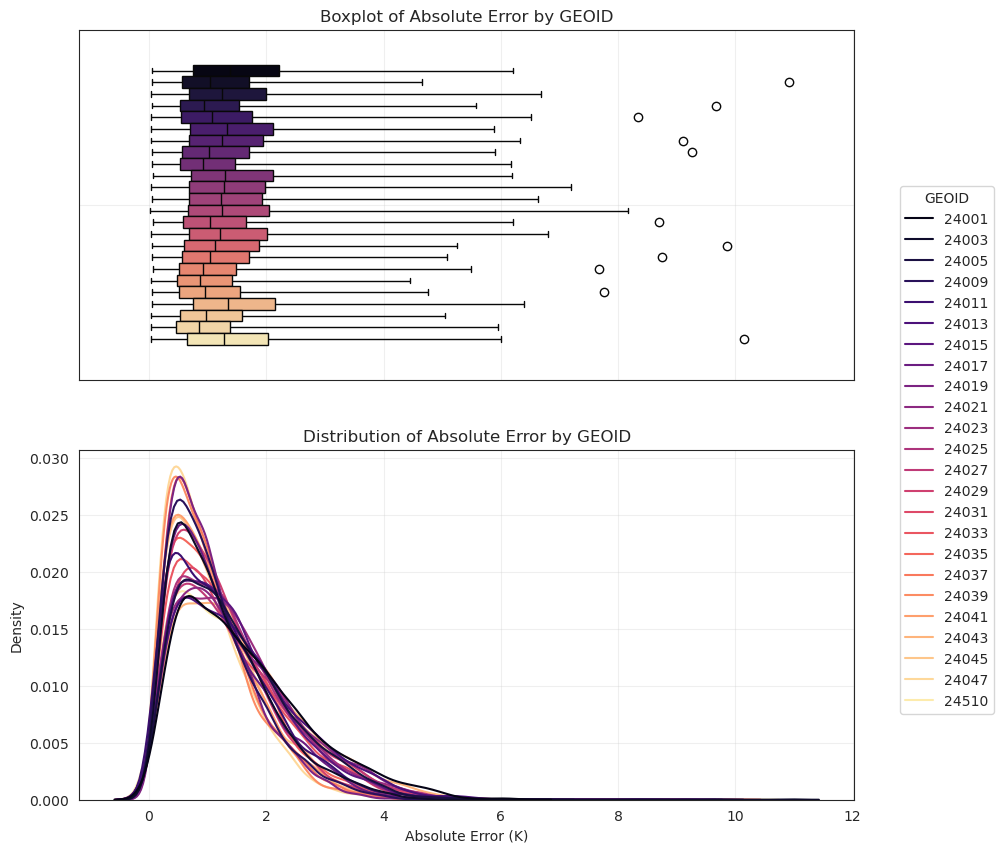

In [25]:
palette = sns.color_palette('magma', n_colors=24)

fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

sns.boxplot(data=MD_error, x='t2m_abs_error', hue='GEOID', whis=5, palette=palette, ax=ax[0], legend=False)
ax[0].set_xlabel('Absolute Error (K)')
ax[0].set_title('Boxplot of Absolute Error by GEOID')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, hue='GEOID', x='t2m_abs_error', palette=palette, ax=ax[1])
ax[1].set_title('Distribution of Absolute Error by GEOID')
ax[1].set_xlabel('Absolute Error (K)')
ax[1].grid(alpha=0.3)

sns.move_legend(ax[1], "center left", bbox_to_anchor=(1.05, 1))
plt.show()

In [26]:
pd.DataFrame(MD_error.groupby('GEOID')['log_t2m_abs_error'].describe())

,count,mean,std,min,25%,50%,75%,max
GEOID,,,,,,,,
24001,3140.0,0.221187,0.776625,-2.851718,-0.281500,0.328062,0.795855,1.826208
24003,3140.0,-0.048923,0.764022,-3.061715,-0.567419,0.034804,0.529436,2.390005
24005,3140.0,0.115735,0.771329,-3.444145,-0.369951,0.220720,0.687151,1.899186
24009,3140.0,-0.149327,0.772101,-2.973713,-0.645196,-0.066477,0.426936,2.268294
24011,3140.0,-0.064943,0.844991,-3.161448,-0.593287,0.080367,0.568164,2.121328
24013,3140.0,0.149466,0.816819,-3.221957,-0.345875,0.287428,0.747021,1.772285
24015,3140.0,0.096140,0.761699,-3.271622,-0.376163,0.214494,0.662640,2.209205
24017,3140.0,-0.058745,0.775915,-3.014216,-0.560275,0.020204,0.535027,2.225964
24019,3140.0,-0.159652,0.732244,-2.942723,-0.641466,-0.083151,0.386768,1.821204


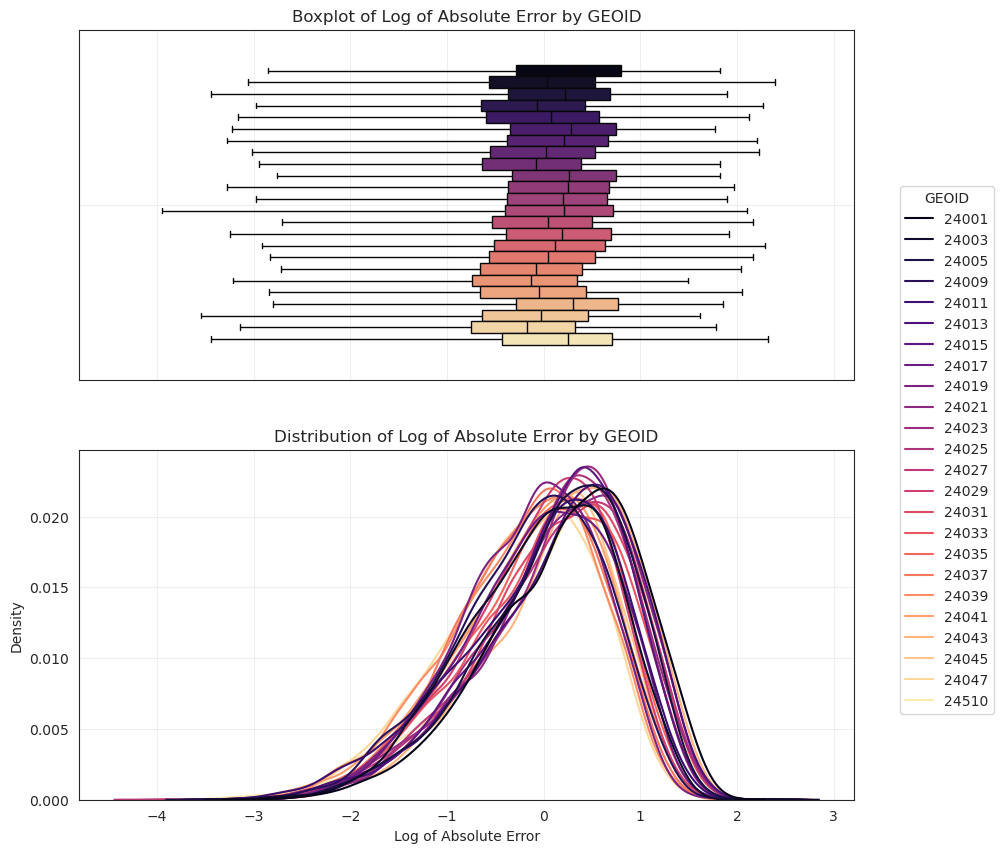

In [27]:
fig, ax = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

sns.boxplot(data=MD_error, x='log_t2m_abs_error', hue='GEOID', whis=5, palette=palette, ax=ax[0], legend=False)
ax[0].set_xlabel('Log of Absolute Error')
ax[0].set_title('Boxplot of Log of Absolute Error by GEOID')
ax[0].grid(alpha=0.3)

sns.kdeplot(data=MD_error, hue='GEOID', x='log_t2m_abs_error', palette=palette, ax=ax[1])
ax[1].set_title('Distribution of Log of Absolute Error by GEOID')
ax[1].set_xlabel('Log of Absolute Error')
ax[1].grid(alpha=0.3)

sns.move_legend(ax[1], "center left", bbox_to_anchor=(1.05, 1))
plt.show()

### Maps

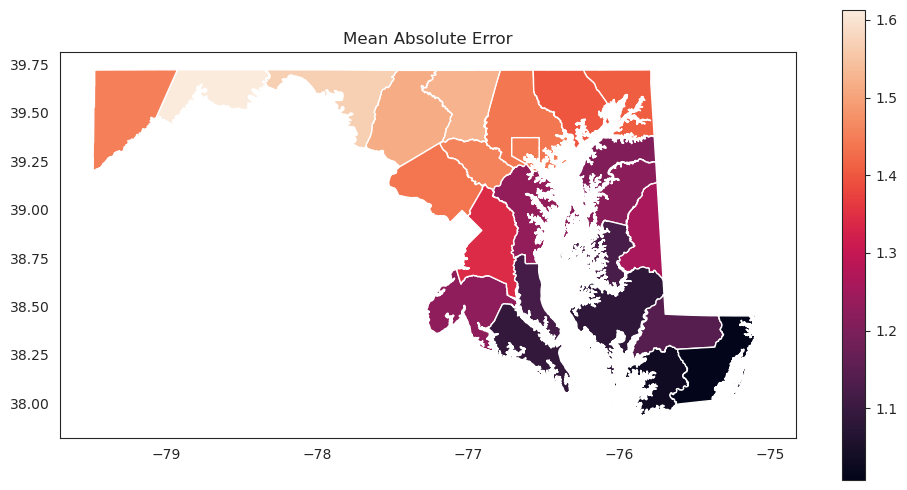

In [28]:
gdf_error = gpd.GeoDataFrame(pd.concat([pd.DataFrame(MD_error.groupby('GEOID')['t2m_abs_error'].mean()), gdf.copy().set_index('GEOID')], axis=1))

fig, ax = plt.subplots(1, figsize=(10,5))
gdf_error.plot(column='t2m_abs_error', legend=True, ax=ax)
plt.title('Mean Absolute Error')
plt.tight_layout()
plt.show()

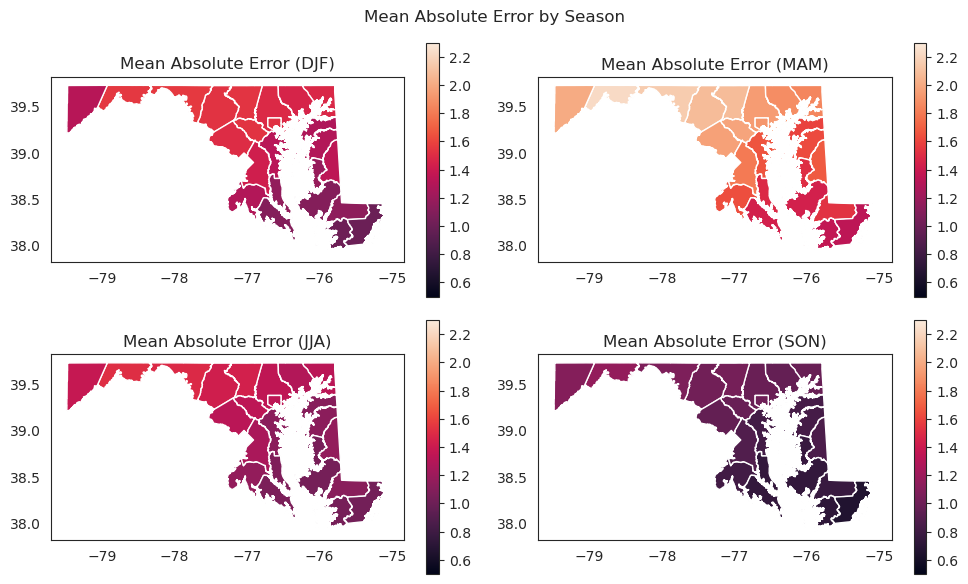

In [29]:
fig, ax = plt.subplots(2,2, figsize=(10,6))

gdf_error_DJF = gpd.GeoDataFrame(pd.concat([pd.DataFrame(MD_error.groupby(['Season','GEOID'])['t2m_abs_error'].mean()['DJF']), gdf.copy().set_index('GEOID')], axis=1))
gdf_error_DJF.plot(column='t2m_abs_error', legend=True, legend_kwds={"shrink":1}, vmin=0.5, vmax=2.3, ax=ax[0,0])
ax[0,0].set_title('Mean Absolute Error (DJF)')

gdf_error_MAM = gpd.GeoDataFrame(pd.concat([pd.DataFrame(MD_error.groupby(['Season','GEOID'])['t2m_abs_error'].mean()['MAM']), gdf.copy().set_index('GEOID')], axis=1))
gdf_error_MAM.plot(column='t2m_abs_error', legend=True, legend_kwds={"shrink":1}, vmin=0.5, vmax=2.3, ax=ax[0,1])
ax[0,1].set_title('Mean Absolute Error (MAM)')

gdf_error_JJA = gpd.GeoDataFrame(pd.concat([pd.DataFrame(MD_error.groupby(['Season','GEOID'])['t2m_abs_error'].mean()['JJA']), gdf.copy().set_index('GEOID')], axis=1))
gdf_error_JJA.plot(column='t2m_abs_error', legend=True, legend_kwds={"shrink":1}, vmin=0.5, vmax=2.3, ax=ax[1,0])
ax[1,0].set_title('Mean Absolute Error (JJA)')

gdf_error_SON = gpd.GeoDataFrame(pd.concat([pd.DataFrame(MD_error.groupby(['Season','GEOID'])['t2m_abs_error'].mean()['SON']), gdf.copy().set_index('GEOID')], axis=1))
gdf_error_SON.plot(column='t2m_abs_error', legend=True, legend_kwds={"shrink":1}, vmin=0.5, vmax=2.3, ax=ax[1,1])
ax[1,1].set_title('Mean Absolute Error (SON)')

plt.suptitle('Mean Absolute Error by Season')
plt.tight_layout()
plt.show()

In [30]:
gdf_census = gpd.GeoDataFrame(pd.concat([df_census_est.copy().set_index('GEOID'), gdf.copy().set_index('GEOID')], axis=1))


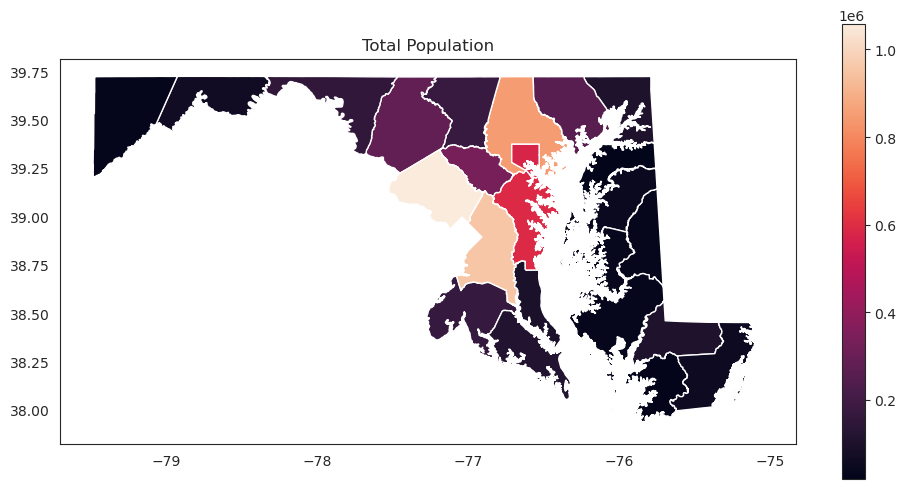

In [31]:
fig, ax = plt.subplots(1, figsize=(10,5))
gdf_census.plot(column='B01001_001', legend=True, ax=ax)
plt.title('Total Population')
plt.tight_layout()
plt.show()

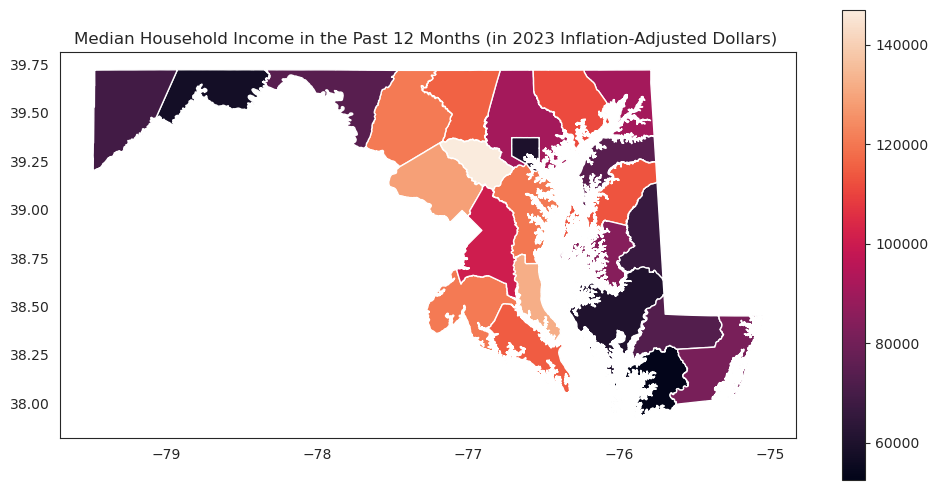

In [32]:
fig, ax = plt.subplots(1, figsize=(10,5))
gdf_census.plot(column='B19013_001', legend=True, ax=ax)
plt.title('Median Household Income in the Past 12 Months (in 2023 Inflation-Adjusted Dollars) ')
plt.tight_layout()
plt.show()